# Ceridwen feature-spectrum posterior report

- load the completed Modal A100 feature-spectrum fit
- summarize direct parameters and derived mass-weighted age
- show posterior marginals and pairwise parameter degeneracies

## 1. Load the stored posterior

- read equal-weight draws and stored SFH quantities
- retain stored indices linking parameters with derived ages

In [1]:
from pathlib import Path

import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
RUN_DIR = (
    PROJECT_ROOT
    / "results/a100-feature-spectrum"
)
DERIVED_PATH = RUN_DIR / "posterior_outputs/ceridwen_derived_outputs.h5"
RESULT_PATH = RUN_DIR / "posterior_outputs/ceridwen_result.h5"

assert DERIVED_PATH.is_file()
assert RESULT_PATH.is_file()

with h5py.File(DERIVED_PATH, "r") as derived:
    run_attrs = dict(derived.attrs)
    equal_weight = derived["posterior/equal_weight"]
    posterior = {name: equal_weight[name][:] for name in equal_weight}
    sfh_indices = derived["sfh/posterior_indices"][:]
    mass_weighted_age = derived["sfh/mass_weighted_age_gyr"][:]
    lookback_time = derived["sfh/lookback_time_gyr"][:]
    sfh_histories = derived["sfh/normalized_sfr_histories"][:]

with h5py.File(RESULT_PATH, "r") as result:
    sampler_attrs = dict(result["samples"].attrs)

assert len(mass_weighted_age) == len(sfh_indices)
assert sfh_indices.max() < len(posterior["logmass"])

run_summary = pd.Series(
    {
        "spectrum mode": run_attrs["spectrum_mode"],
        "likelihood pixels": int(run_attrs["likelihood_pixels"]),
        "equal-weight draws": len(posterior["logmass"]),
        "age-linked SFH draws": len(mass_weighted_age),
        "posterior-weight ESS": run_attrs["posterior_weight_ess"],
        "likelihood calls": int(run_attrs["likelihood_calls"]),
        "sampler wall time [h]": run_attrs["sampler_wall_time_s"] / 3600,
        "ln evidence": sampler_attrs["log_evidence"],
        "ln evidence uncertainty": sampler_attrs["log_evidence_err"],
        "diagnostics passed": bool(run_attrs["diagnostics_passed"]),
    },
    name="value",
).to_frame()
display(run_summary)

,value
spectrum mode,features
likelihood pixels,1924
equal-weight draws,2000
age-linked SFH draws,400
posterior-weight ESS,3416.43983
likelihood calls,1146000
sampler wall time [h],3.015997
ln evidence,125739.80842
ln evidence uncertainty,0.176058
diagnostics passed,True


## 2. Build readable parameter posteriors

- Ceridwen samples seven $\log\mathrm{SFR}$ ratios
- mass-weighted age is calculated from each sampled SFH
- use aligned draws when plotting age correlations

In [2]:
ratio_labels = [
    rf"$\log(\mathrm{{SFR}}_{{{index + 1}}}/\mathrm{{SFR}}_{{{index + 2}}})$"
    for index in range(posterior["logsfr_ratios"].shape[1])
]
parameter_values = {
    r"$t_{\mathrm{MW}}$ [Gyr]": mass_weighted_age,
    r"$\log M$ [slit aperture]": posterior["logmass"],
    r"$[Z/H]$": posterior["Z"],
    r"$[\alpha/\mathrm{Fe}]$": posterior["afe"],
    r"$\tau_{\mathrm{dust}}$": posterior["diffuse_tau_kc"],
    "calibration floor [%]": 100 * np.exp(posterior["log_f_calib"]),
}
for index, label in enumerate(ratio_labels):
    parameter_values[label] = posterior["logsfr_ratios"][:, index]


def posterior_interval(label, values):
    q16, median, q84 = np.percentile(values, [16, 50, 84])
    return {
        "parameter": label,
        "q16": q16,
        "median": median,
        "q84": q84,
        "minus": median - q16,
        "plus": q84 - median,
    }


summary_table = pd.DataFrame(
    posterior_interval(label, values)
    for label, values in parameter_values.items()
).set_index("parameter")
display(summary_table.round(4))

,q16,median,q84,minus,plus
parameter,,,,,
$t_{\mathrm{MW}}$ [Gyr],2.8012,2.8387,2.8887,0.0375,0.0500
$\log M$ [slit aperture],11.5816,11.5921,11.6025,0.0105,0.0104
$[Z/H]$,-1.3831,-1.3515,-1.3193,0.0316,0.0322
$[\alpha/\mathrm{Fe}]$,0.1129,0.1248,0.1357,0.0119,0.0108
$\tau_{\mathrm{dust}}$,0.4607,0.4787,0.4951,0.0180,0.0164
calibration floor [%],3.8171,3.8925,3.9689,0.0753,0.0764
$\log(\mathrm{SFR}_{1}/\mathrm{SFR}_{2})$,1.4651,2.1880,2.7666,0.7229,0.5785
$\log(\mathrm{SFR}_{2}/\mathrm{SFR}_{3})$,0.0024,1.1648,2.2153,1.1624,1.0505
$\log(\mathrm{SFR}_{3}/\mathrm{SFR}_{4})$,-2.2560,-1.1146,0.0255,1.1414,1.1400


## 3. Inspect every one-dimensional posterior

- show all direct parameters and the derived age
- mark median and central 68-percent intervals

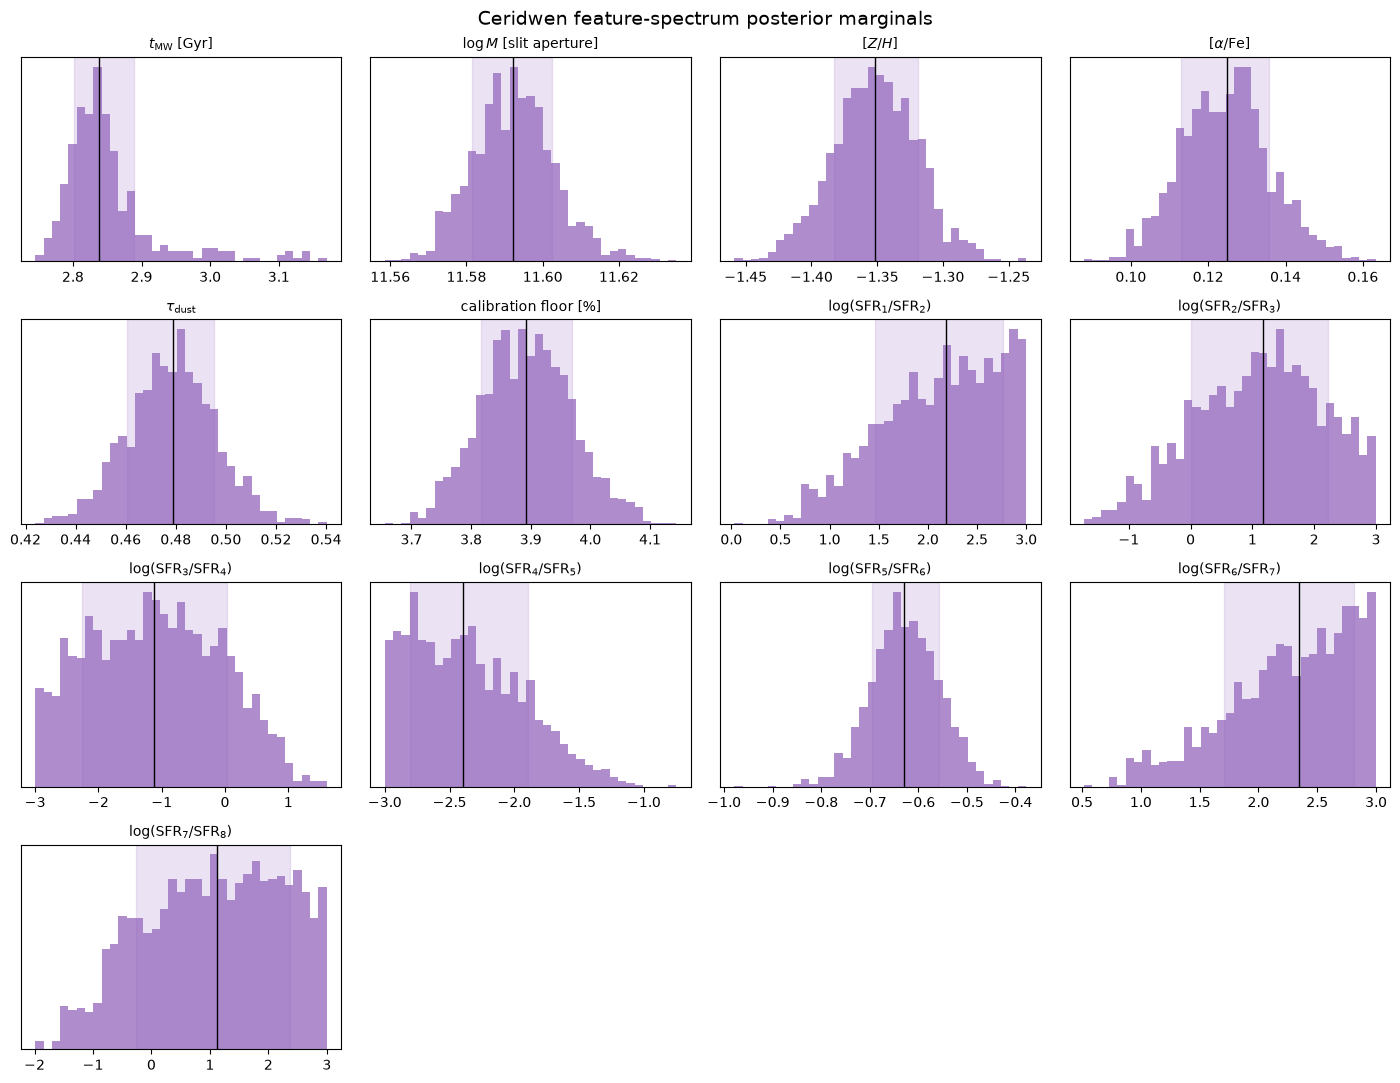

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(14, 11))
flat_axes = axes.ravel()
for axis, (label, values) in zip(flat_axes, parameter_values.items(), strict=False):
    q16, median, q84 = np.percentile(values, [16, 50, 84])
    axis.hist(values, bins=35, density=True, color="tab:purple", alpha=0.75)
    axis.axvspan(q16, q84, color="tab:purple", alpha=0.18)
    axis.axvline(median, color="black", linewidth=1)
    axis.set_title(label, fontsize=10)
    axis.set_yticks([])
for axis in flat_axes[len(parameter_values) :]:
    axis.remove()
fig.suptitle("Ceridwen feature-spectrum posterior marginals", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Inspect physical-parameter degeneracies

- include mass-weighted age with stellar-population parameters
- use the 400 draws carrying matched SFH ages

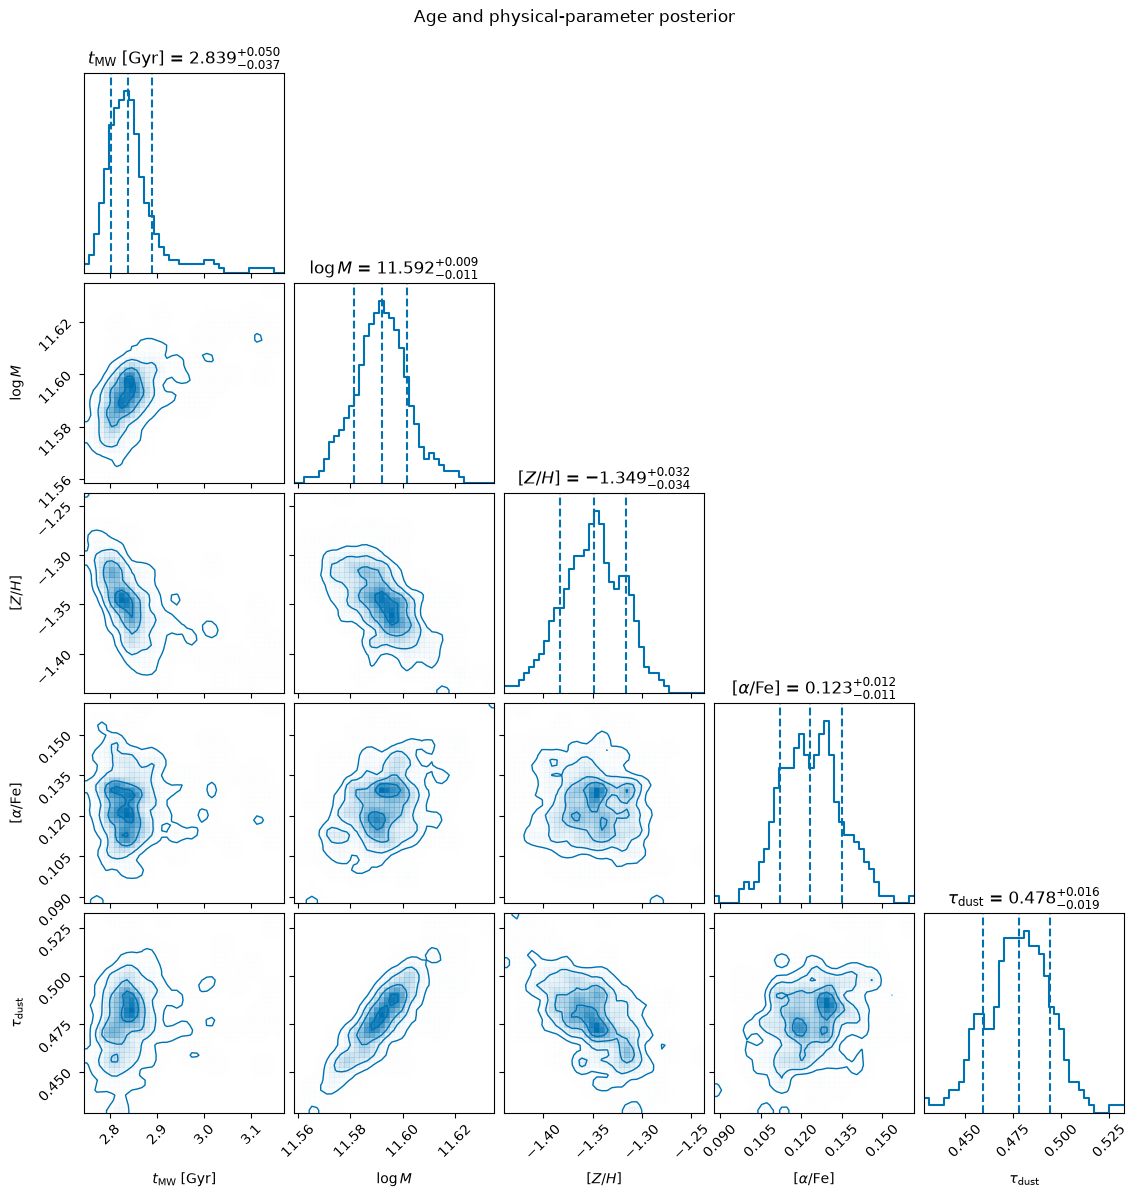

In [4]:
physical_corner = np.column_stack(
    [
        mass_weighted_age,
        posterior["logmass"][sfh_indices],
        posterior["Z"][sfh_indices],
        posterior["afe"][sfh_indices],
        posterior["diffuse_tau_kc"][sfh_indices],
    ]
)
physical_labels = [
    r"$t_{\mathrm{MW}}$ [Gyr]",
    r"$\log M$",
    r"$[Z/H]$",
    r"$[\alpha/\mathrm{Fe}]$",
    r"$\tau_{\mathrm{dust}}$",
]
CORNER_STYLE = {
    "bins": 40,
    "color": "#0072B2",
    "smooth": 1.2,
    "smooth1d": 1.0,
    "plot_datapoints": False,
    "plot_density": True,
    "plot_contours": True,
    "fill_contours": False,
    "hist_kwargs": {"linewidth": 1.5},
    "contour_kwargs": {"linewidths": 1.0},
}

physical_figure = corner.corner(
    physical_corner,
    labels=physical_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    **CORNER_STYLE,
)
physical_figure.suptitle("Age and physical-parameter posterior", y=1.02)
plt.show()

## 5. Connect the SFH with its derived age

- pair the stored SFH band with age posterior
- inspect age against early, middle, and late ratios

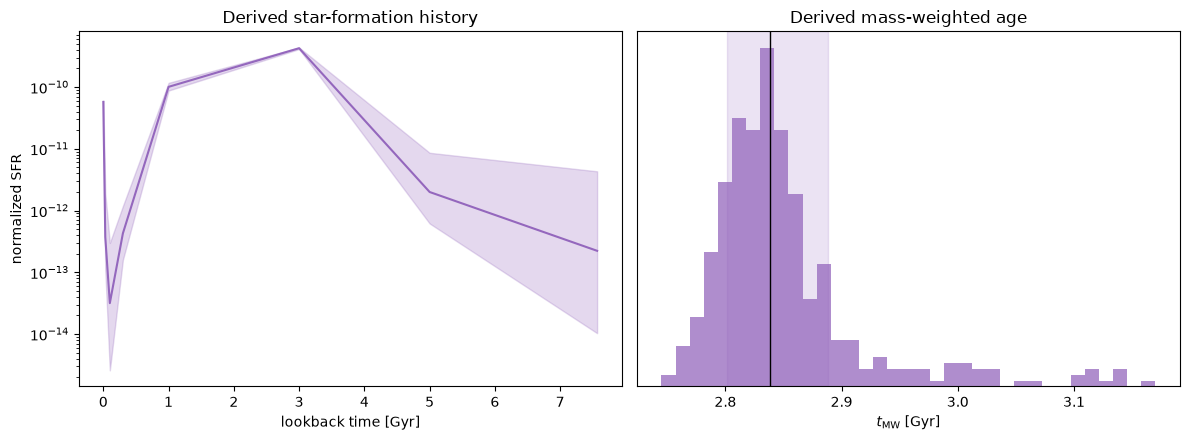

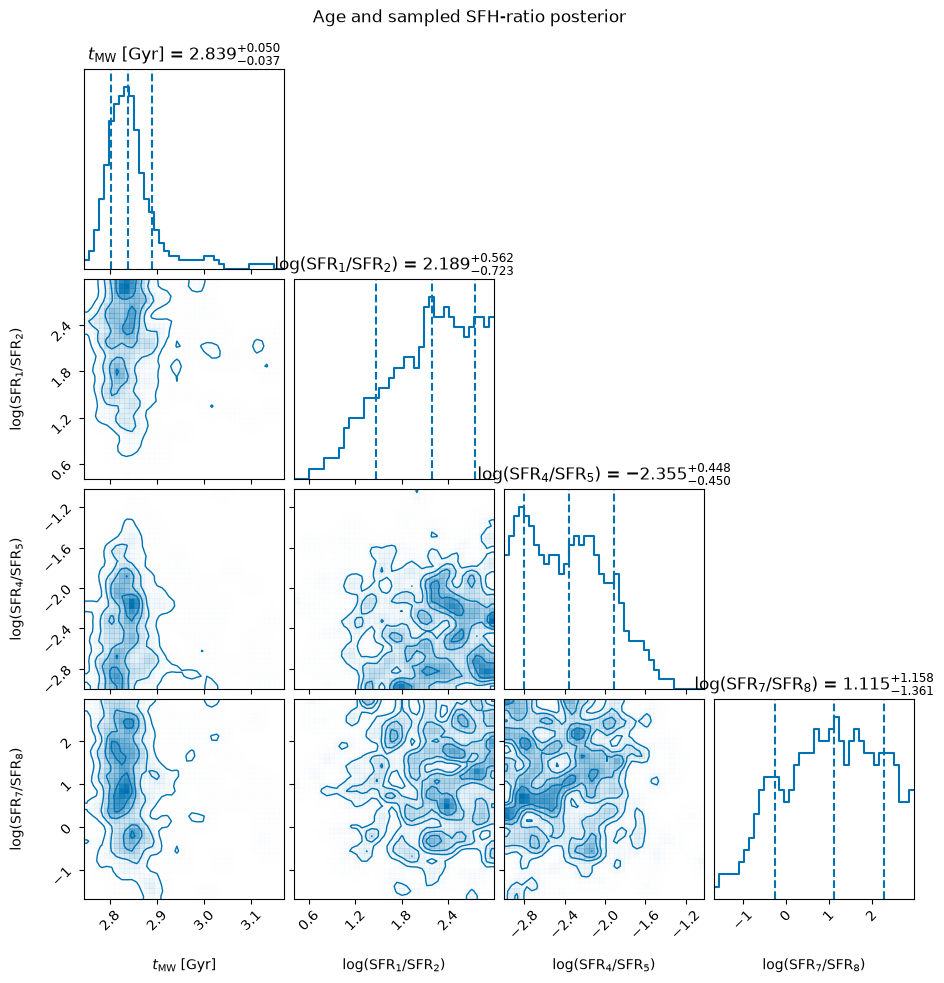

In [5]:
sfh_q16, sfh_q50, sfh_q84 = np.percentile(
    sfh_histories, [16, 50, 84], axis=0
)
age_q16, age_median, age_q84 = np.percentile(
    mass_weighted_age, [16, 50, 84]
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(lookback_time, sfh_q50, color="tab:purple")
axes[0].fill_between(
    lookback_time, sfh_q16, sfh_q84, color="tab:purple", alpha=0.25
)
axes[0].set(
    yscale="log",
    xlabel="lookback time [Gyr]",
    ylabel="normalized SFR",
    title="Derived star-formation history",
)
axes[1].hist(
    mass_weighted_age, bins=35, density=True, color="tab:purple", alpha=0.75
)
axes[1].axvspan(age_q16, age_q84, color="tab:purple", alpha=0.18)
axes[1].axvline(age_median, color="black", linewidth=1)
axes[1].set(
    xlabel=r"$t_{\mathrm{MW}}$ [Gyr]",
    yticks=[],
    title="Derived mass-weighted age",
)
fig.tight_layout()
plt.show()

selected_ratios = [0, 3, 6]
age_sfh_corner = np.column_stack(
    [mass_weighted_age]
    + [
        posterior["logsfr_ratios"][sfh_indices, index]
        for index in selected_ratios
    ]
)
age_sfh_labels = [r"$t_{\mathrm{MW}}$ [Gyr]"] + [
    ratio_labels[index] for index in selected_ratios
]
age_sfh_figure = corner.corner(
    age_sfh_corner,
    labels=age_sfh_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    **CORNER_STYLE,
)
age_sfh_figure.suptitle("Age and sampled SFH-ratio posterior", y=1.02)
plt.show()

## 6. Interpretation boundary

- age is derived, not an independently sampled parameter
- age correlations use 400 matched posterior SFH draws
- feature and full-spectrum evidences are not directly comparable